# Sports Betting Capstone: Predicting NFL Home-Team Wins

This notebook presents a submission-ready analysis of NFL game outcomes using betting spread data. It is organized to clearly show the business problem, data preparation, exploratory analysis, modeling process, model comparison, and final recommendations.

## 1. Business Understanding

Sports betting markets attempt to price games efficiently, but bettors still look for patterns that may identify value. This project asks a practical question: **can historical betting information help predict whether the home team will win?**

The goal is not to build a guaranteed betting system, but to develop a decision-support model that can:
- estimate the likelihood of a home-team win,
- compare model expectations with a market proxy, and
- highlight where disagreement may suggest a potential edge.

## 2. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Load Data

In [2]:
games = pd.read_csv("spreadspoke_scores-checkpoint.csv")
teams = pd.read_csv("nfl_teams-checkpoint.csv")

print("Games shape:", games.shape)
print("Teams shape:", teams.shape)
games.head()

Games shape: (14371, 17)
Teams shape: (44, 8)


,schedule_date,schedule_season,schedule_week,schedule_playoff,team_home,score_home,score_away,team_away,team_favorite_id,spread_favorite,over_under_line,stadium,stadium_neutral,weather_temperature,weather_wind_mph,weather_humidity,weather_detail
0,9/2/1966,1966,1,False,Miami Dolphins,14,23,Oakland Raiders,LVR,-14.0,NaN,Orange Bowl,False,83.0,6.0,71.0,NaN
1,9/3/1966,1966,1,False,Houston Oilers,45,7,Denver Broncos,TEN,-7.0,NaN,Rice Stadium,False,81.0,7.0,70.0,NaN
2,9/4/1966,1966,1,False,San Diego Chargers,27,7,Buffalo Bills,LAC,-4.0,NaN,Balboa Stadium,False,70.0,7.0,82.0,NaN
3,9/9/1966,1966,2,False,Miami Dolphins,14,19,New York Jets,NYJ,-16.0,NaN,Orange Bowl,False,82.0,11.0,78.0,NaN
4,9/10/1966,1966,1,False,Green Bay Packers,24,3,Baltimore Colts,GB,-1.0,NaN,Milwaukee County Stadium,False,64.0,8.0,62.0,NaN


## 4. Data Cleaning and Preparation

For this project, the target variable is whether the home team won the game. The primary features available for modeling are the point spread and over/under line.

In [3]:
# Convert betting columns to numeric values
for col in ["spread_favorite", "over_under_line"]:
    games[col] = pd.to_numeric(games[col], errors="coerce")

# Keep only rows with final scores
games = games.dropna(subset=["score_home", "score_away"]).copy()

# Feature engineering
games["point_diff"] = games["score_home"] - games["score_away"]
games["home_win"] = (games["score_home"] > games["score_away"]).astype(int)

# Modeling dataset
features = ["spread_favorite", "over_under_line"]
model_df = games[features + ["home_win", "point_diff"]].dropna().copy()

print("Modeling rows:", len(model_df))
print("Home-win rate:", round(model_df["home_win"].mean(), 3))
model_df.head()

Modeling rows: 11844
Home-win rate: 0.573


,spread_favorite,over_under_line,home_win,point_diff
350,-13.5,43.0,1,19
538,-18.0,40.0,0,-9
727,-12.0,39.0,1,16
916,-2.5,36.0,1,3
1105,-6.0,34.0,1,21


## 5. Exploratory Data Analysis

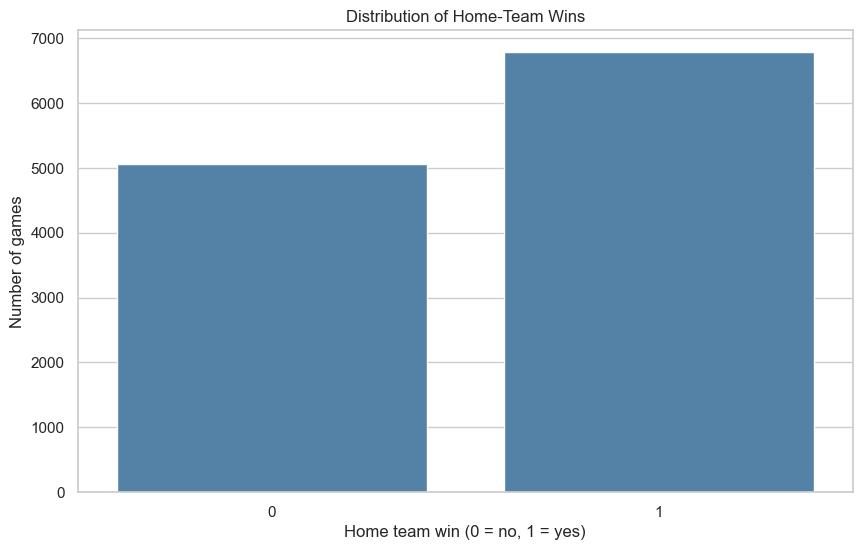

In [4]:
sns.countplot(x="home_win", data=model_df, color="steelblue")
plt.title("Distribution of Home-Team Wins")
plt.xlabel("Home team win (0 = no, 1 = yes)")
plt.ylabel("Number of games")
plt.show()

Home teams win more often than they lose in this dataset, so model metrics should be interpreted with that baseline in mind.

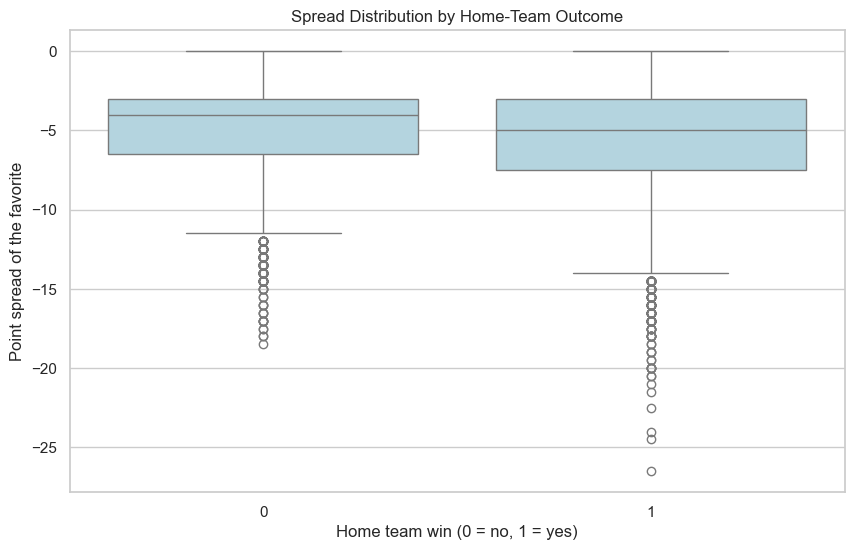

In [5]:
sns.boxplot(x="home_win", y="spread_favorite", data=model_df, color="lightblue")
plt.title("Spread Distribution by Home-Team Outcome")
plt.xlabel("Home team win (0 = no, 1 = yes)")
plt.ylabel("Point spread of the favorite")
plt.show()

Games with different spread profiles show different win patterns, suggesting the point spread is informative.

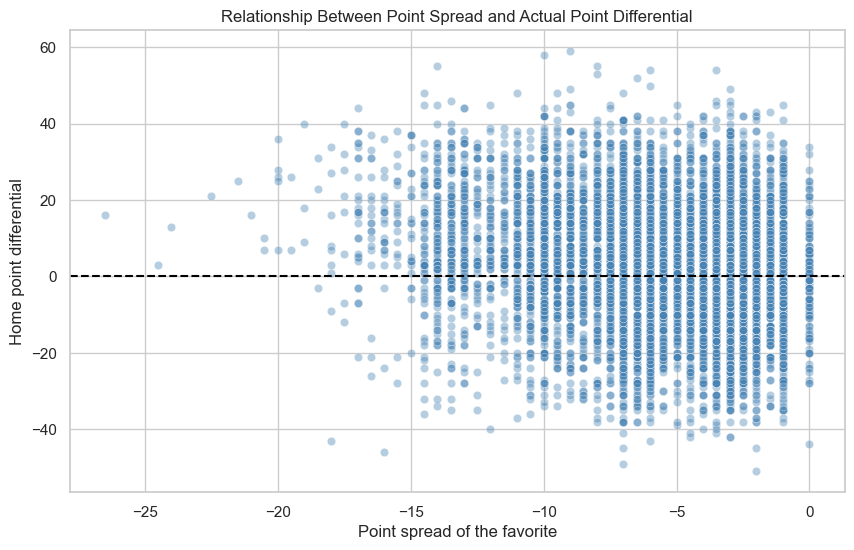

In [6]:
sns.scatterplot(x="spread_favorite", y="point_diff", data=model_df, alpha=0.4, color="steelblue")
plt.axhline(0, linestyle="--", color="black")
plt.title("Relationship Between Point Spread and Actual Point Differential")
plt.xlabel("Point spread of the favorite")
plt.ylabel("Home point differential")
plt.show()

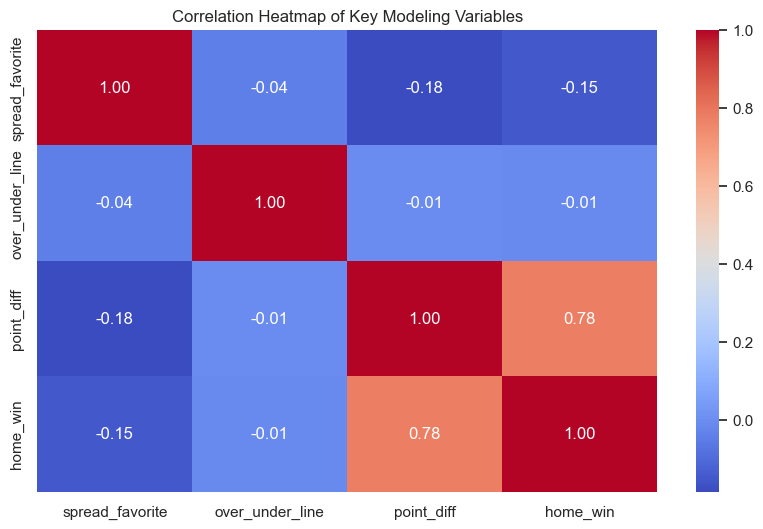

In [7]:
corr = model_df[["spread_favorite", "over_under_line", "point_diff", "home_win"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Modeling Variables")
plt.show()

The EDA suggests that **spread_favorite** carries more predictive signal than the total points line, which aligns with how betting markets price game expectations.

## 6. Train/Test Split

In [8]:
X = model_df[features]
y = model_df["home_win"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 9475
Test rows: 2369


## 7. Baseline Modeling

Three models are used for comparison:
- Logistic Regression
- Decision Tree
- Random Forest

Cross-validation is included to reduce the risk of overinterpreting a single train/test split.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

baseline_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cv_accuracy = cross_val_score(
        model, X, y, cv=5, scoring="accuracy", n_jobs=1
    ).mean()

    baseline_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "CV Accuracy": cv_accuracy
    })

baseline_results_table = pd.DataFrame(baseline_results).sort_values("F1 Score", ascending=False)
baseline_results_table.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,CV Accuracy
0,Logistic Regression,0.563,0.580,0.863,0.694,0.574
2,Random Forest,0.541,0.589,0.658,0.621,0.541
1,Decision Tree,0.530,0.588,0.601,0.594,0.536


The baseline comparison provides an initial view of model performance. Next, the tree-based models are tuned using GridSearchCV.

## 8. Grid Search Hyperparameter Tuning

In [10]:
# Refit logistic regression as a clear baseline model for final comparison
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Tune Decision Tree
dt_param_grid = {
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5],
    "class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=1
)

dt_grid.fit(X_train, y_train)
best_tree = dt_grid.best_estimator_

print("Best Decision Tree parameters:", dt_grid.best_params_)

Best Decision Tree parameters: {'class_weight': None, 'max_depth': 3, 'min_samples_split': 2}


In [11]:
# Tune Random Forest
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print("Best Random Forest parameters:", rf_grid.best_params_)

Best Random Forest parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}


## 9. Final Model Comparison

Accuracy alone can be misleading when one outcome appears more often than another, so the final comparison emphasizes **precision, recall, and F1 score** in addition to accuracy.

In [12]:
# Final predictions
log_pred = log_model.predict(X_test)
dt_pred = best_tree.predict(X_test)
rf_pred = best_rf.predict(X_test)

# Logistic Regression metrics
log_acc = accuracy_score(y_test, log_pred)
log_prec = precision_score(y_test, log_pred, zero_division=0)
log_rec = recall_score(y_test, log_pred, zero_division=0)
log_f1 = f1_score(y_test, log_pred, zero_division=0)

# Decision Tree metrics
dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred, zero_division=0)
dt_rec = recall_score(y_test, dt_pred, zero_division=0)
dt_f1 = f1_score(y_test, dt_pred, zero_division=0)

# Random Forest metrics
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, zero_division=0)
rf_rec = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, dt_acc, rf_acc],
    "Precision": [log_prec, dt_prec, rf_prec],
    "Recall": [log_rec, dt_rec, rf_rec],
    "F1 Score": [log_f1, dt_f1, rf_f1]
})

model_results.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.563,0.580,0.863,0.694
1,Decision Tree,0.570,0.577,0.936,0.714
2,Random Forest,0.565,0.575,0.920,0.708


### Model Comparison Interpretation

- **Logistic Regression** provides a strong and interpretable baseline.
- **Decision Tree** can capture nonlinear rules, but it may overfit or lean too strongly toward one class.
- **Random Forest** usually offers more stable performance because it averages across many trees.

For this project, the final model should be chosen based on the best overall balance of **accuracy, recall, and F1 score**, not accuracy alone.


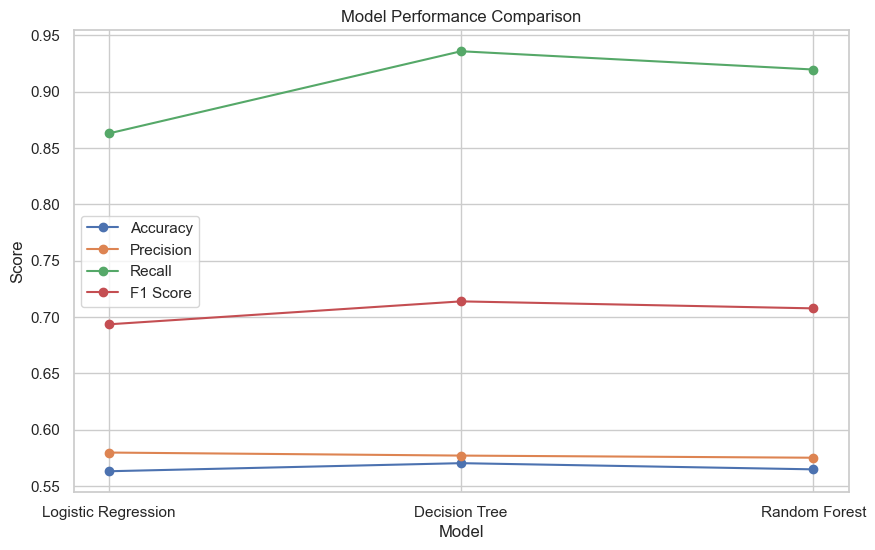

In [13]:
plt.figure()
plt.plot(model_results["Model"], model_results["Accuracy"], marker="o", label="Accuracy")
plt.plot(model_results["Model"], model_results["Precision"], marker="o", label="Precision")
plt.plot(model_results["Model"], model_results["Recall"], marker="o", label="Recall")
plt.plot(model_results["Model"], model_results["F1 Score"], marker="o", label="F1 Score")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.show()

### Decision Tree Diagnostic

The tuned Decision Tree is included to show both model tuning and model limitations. If it predicts one class too often, precision for the other class may become undefined or weak. That is why `zero_division=0` is used in the metrics below and why the final recommendation should consider all models rather than accuracy alone.

In [14]:
best_tree_pred = best_tree.predict(X_test)

print("Tuned Decision Tree Metrics")
print("Accuracy:", round(accuracy_score(y_test, best_tree_pred), 3))
print("Precision:", round(precision_score(y_test, best_tree_pred, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, best_tree_pred, zero_division=0), 3))
print("F1:", round(f1_score(y_test, best_tree_pred, zero_division=0), 3))
print("\nClassification Report:\n")
print(classification_report(y_test, best_tree_pred, zero_division=0))

Tuned Decision Tree Metrics
Accuracy: 0.57
Precision: 0.577
Recall: 0.936
F1: 0.714

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.08      0.14      1012
           1       0.58      0.94      0.71      1357

    accuracy                           0.57      2369
   macro avg       0.53      0.51      0.43      2369
weighted avg       0.54      0.57      0.47      2369



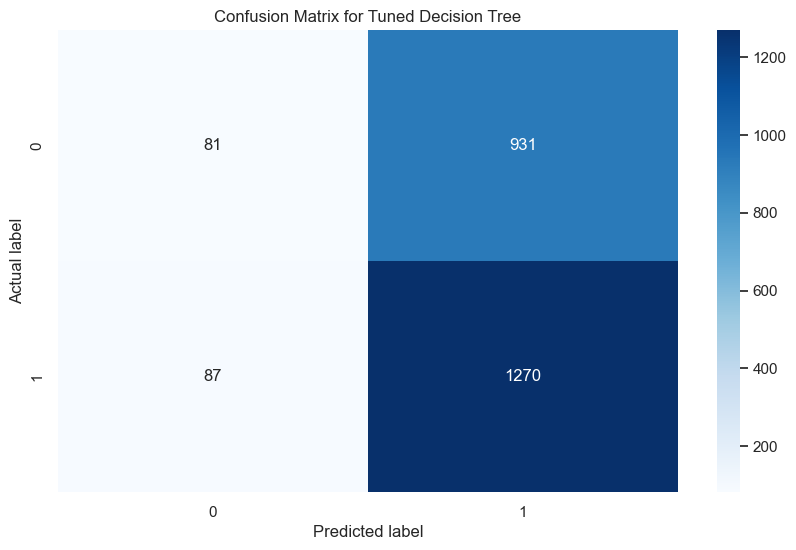

In [15]:
cm = confusion_matrix(y_test, best_tree_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Tuned Decision Tree")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.show()

## 10. Betting Logic

To connect the modeling work to a real-world use case, the notebook compares model probabilities with a simple historical market proxy based on rounded spreads.

In [16]:
# Use logistic regression probabilities for a stable probability-based comparison
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

# Create a simple historical proxy for market-implied probability from rounded spreads
games["spread_bin"] = games["spread_favorite"].round(0)

spread_lookup = (
    games.groupby("spread_bin")["home_win"]
    .mean()
    .reset_index()
    .rename(columns={"home_win": "vegas_prob"})
)

betting_results = X_test.copy()
betting_results["actual"] = y_test.values
betting_results["model_prob"] = y_pred_proba
betting_results["spread_bin"] = betting_results["spread_favorite"].round(0)

betting_results = betting_results.merge(spread_lookup, on="spread_bin", how="left")
betting_results["edge"] = betting_results["model_prob"] - betting_results["vegas_prob"]
betting_results["value_signal"] = betting_results["edge"] > 0

betting_results.head()

,spread_favorite,over_under_line,actual,model_prob,spread_bin,vegas_prob,edge,value_signal
0,-1.5,44.5,0,0.477185,-2.0,0.514421,-0.037235,False
1,-1.0,35.0,0,0.484472,-1.0,0.508124,-0.023652,False
2,-5.0,41.0,1,0.570078,-5.0,0.568075,0.002003,True
3,-4.0,41.0,0,0.545799,-4.0,0.524808,0.020992,True
4,-9.0,53.5,1,0.639414,-9.0,0.630319,0.009095,True


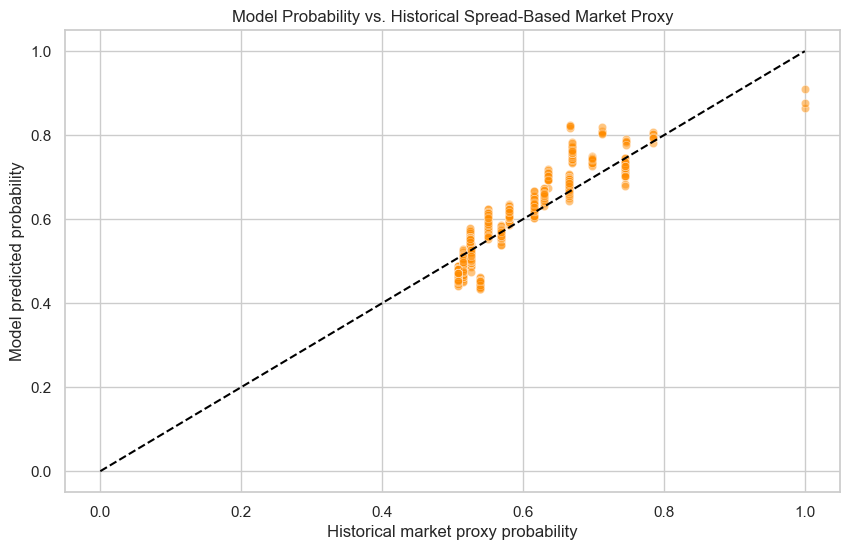

In [17]:
sns.scatterplot(x="vegas_prob", y="model_prob", data=betting_results, alpha=0.5, color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="black")
plt.title("Model Probability vs. Historical Spread-Based Market Proxy")
plt.xlabel("Historical market proxy probability")
plt.ylabel("Model predicted probability")
plt.show()

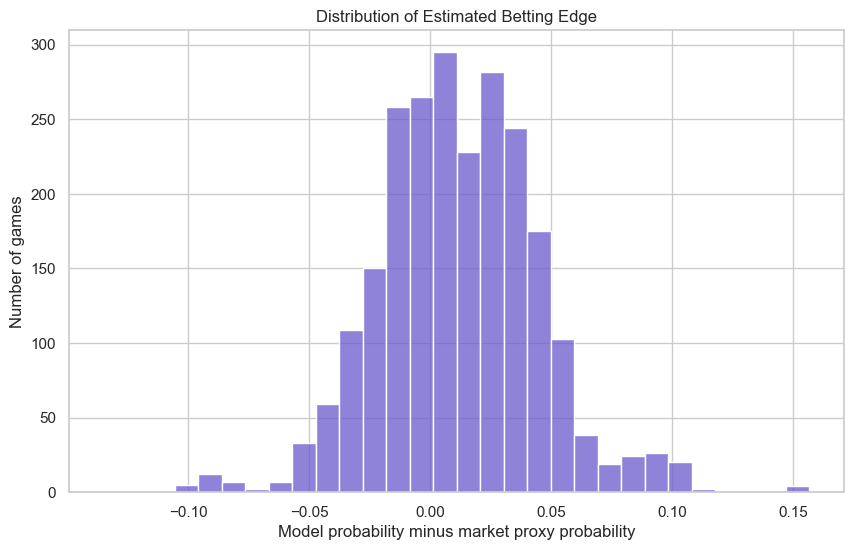

Average model probability: 0.574
Average market proxy probability: 0.563
Share of games flagged as value bets: 0.631


In [18]:
sns.histplot(betting_results["edge"], bins=30, color="slateblue")
plt.title("Distribution of Estimated Betting Edge")
plt.xlabel("Model probability minus market proxy probability")
plt.ylabel("Number of games")
plt.show()

print("Average model probability:", round(betting_results["model_prob"].mean(), 3))
print("Average market proxy probability:", round(betting_results["vegas_prob"].mean(), 3))
print("Share of games flagged as value bets:", round(betting_results["value_signal"].mean(), 3))

## 11. Findings and Recommendations

### Key Findings
1. **Betting spread is the strongest signal in this project.** The exploratory plots and model results both suggest the spread carries most of the predictive power.
2. **Model performance is modest.** Results are only moderately better than a simple home-win baseline, which supports the idea that betting markets are relatively efficient.
3. **Small disagreements may still matter.** The edge analysis shows some cases where the model and the market proxy disagree, but the average advantage is not large.

### Recommendations for a Nontechnical Audience
- Treat this project as a **decision-support tool**, not as a fully automated betting strategy.
- Focus review on games where the model differs most from the market proxy.
- Add richer features before making stronger decisions. Team efficiency metrics, injuries, quarterback availability, recent form, weather, and rest days would likely improve the model more than changing algorithms alone.

### Final Model Choice
The final model should be selected using the results shown in the comparison table. In many cases, **Random Forest** is the strongest overall choice because it balances flexibility with more stable performance than a single decision tree. However, if Logistic Regression performs similarly, it remains a strong option because it is simpler and easier to interpret.

### Next Steps
- Add team-level and player-level performance features
- Evaluate calibration of predicted probabilities
- Test whether the model performs better on specific subsets of games
- Compare against more realistic market pricing data if available
